<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/assignments/06_Assignment_survival_analysis_Part1_2_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPM 204 Assignment: Survival Analysis

### Instructions
1. For all questions, output should be displayed in the notebook. If working together, give credit to the contributing member. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
2. DO NOT BLINDLY COPY CODE; use of AI Chatbot, while discouraged is allowed. Using Chatbots drastically reduce understanding especially when learning new code or techniques, see [Wu & Yu 2023](https://doi.org/10.1111/bjet.13334) and [Abbas et al. 2024](https://doi.org/10.1186/s41239-024-00444-7). If you plan to use Chatbots, use them to understand bits of code and the technique under study, do not use them to do coding for you.
3. Additionally, please provide the colab notebook after adding the necessary segments and code chunks along with the outputs.
4. To answer text-based (non-code) questions, use a text chunk. It can be created by hovering over the previous chunk and clicking on `+Text` or clicking on `+Text` on the left top corner of your command bar.

Total maximum points =
 - Part 0:  0
 - Part 1:  5
 - Part 2:  5
 - Part 3:  10 + 2 (bonus)
 - Part 4:  5
 - Part 5:  5 + 1 (bonus)
 - **Total max:   30**


# Part 0
Load the `surv_cow.csv` data into the Colab workspace and read into R workspace in this notebook. Load/ install required packages:
 - `survival`
 - `survminer`
 - `ggplot2`
The dataset contains the following columns:
1. `$cowID`: Unique cow identifier
2. `$birth_date`: Birth_date in yyyy-mm-dd
3. `$scc`: Observed Somatic Cell Count ÷ 1000
4. `$obs_date`: Observation date in yyyy-mm-dd
5. `$daily_milk`: Observed milk production in pounds (lb)
6. `$event`: Event variable (binary 0/1)
7. `$lactation`: Number of lactations
**NOTE: The dataset will be available on canvas or distributed during the lecture on survival analysis. If the dataset is not available, reach out before proceeding with this assignment.**

In [2]:
install.packages("survival")
install.packages("survminer")
library(survival)
library(survminer)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘ggtext’


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [9]:
surv_cow <- read.csv("surv_cow.csv")

# Part 1 (points: 5)

Summarize the dataset and answer the following questions: (max points for questions = 4)
1. Which variables are categorical and which are continuous? (1)
2. Which variables are potentially independent variables/ explanatory variables? (0.5)
3. How many cows do our dataset represent? (0.5)
4. The `surv_cow$event` is the event variable. What does the 0 and 1 values represent? [Hint: Read censoring and truncation] (1)
5. How many missing values in `$scc` and `$daily_milk` respectively? Are they missing at random or is their a possible reason why they are missing? (1)

[Hint: `table(is.na(surv_cow$scc), surv_cow$_____)`]

ANSWERS:

1) Categorical: cowID, event, lactation

    Continuous: scc, daily_milk, birth_date, obs_date

2) Potential independent variables: daily_milk, lactation, scc, event

3) 20 cows

4) With the event varaible, 0 means the event did not occur, and 1 means the event occurred.

5) Missing values for scc are 89 and $daily_milk are 89. They are not missing at random because they both fall in the 0 columns after running the code. If there were random, they would be more scattered across column 0 and 1.

In [10]:
# complete this code chunk for Part 1 (0.5 points)
summary(surv_cow)
str(surv_cow)

     cowID           birth_date       scc              obs_date  
 Min.   : 1.00   Length   :320   Min.   : 130.0   Length   :320  
 1st Qu.: 5.75   N.unique : 14   1st Qu.: 493.5   N.unique :302  
 Median :10.50   N.blank  :  0   Median : 878.0   N.blank  :  0  
 Mean   :10.50   Min.nchar: 10   Mean   : 989.5   Min.nchar: 10  
 3rd Qu.:15.25   Max.nchar: 10   3rd Qu.:1187.5   Max.nchar: 10  
 Max.   :20.00                   Max.   :5872.0                  
                                 NAs    :89                      
   daily_milk         event          lactation    
 Min.   : 40.14   Min.   :0.0000   Min.   :0.000  
 1st Qu.: 93.40   1st Qu.:0.0000   1st Qu.:0.000  
 Median :120.93   Median :0.0000   Median :2.000  
 Mean   :150.73   Mean   :0.0625   Mean   :2.166  
 3rd Qu.:180.32   3rd Qu.:0.0000   3rd Qu.:3.250  
 Max.   :720.71   Max.   :1.0000   Max.   :7.000  
 NAs    :89                                       

'data.frame':	320 obs. of  7 variables:
 $ cowID     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ birth_date: chr  "2015-02-27" "2015-02-27" "2015-02-27" "2015-02-27" ...
 $ scc       : int  NA NA NA 1852 3091 1669 1090 1982 993 438 ...
 $ obs_date  : chr  "2015-08-30" "2016-02-23" "2016-06-01" "2017-05-27" ...
 $ daily_milk: num  NA NA NA 394 204 ...
 $ event     : int  0 0 0 0 0 0 0 0 0 0 ...
 $ lactation : int  0 0 0 1 1 1 2 2 3 4 ...


In [11]:
table(is.na(surv_cow$scc),        surv_cow$event)
table(is.na(surv_cow$daily_milk),  surv_cow$event)

       
          0   1
  FALSE 211  20
  TRUE   89   0

       
          0   1
  FALSE 211  20
  TRUE   89   0

In [12]:
# complete this code chunk for Part 1 (0.5 points)
surv_cow$birth_date <- as.Date(surv_cow$birth_date, format = "%Y-%m-%d")
surv_cow$obs_date   <- as.Date(surv_cow$obs_date,   format = "%Y-%m-%d")

# surv_time = how long the cow was observed = age at observation
surv_cow$surv_time  <- surv_cow$obs_date - surv_cow$birth_date

surv_cow$lactation  <- as.factor(surv_cow$lactation)

# Drop rows with missing values in ANY column
surv_cow <- surv_cow[complete.cases(surv_cow), ]

head(surv_cow)

,cowID,birth_date,scc,obs_date,daily_milk,event,lactation,surv_time
,<int>,<date>,<int>,<date>,<dbl>,<int>,<fct>,<drtn>
4,1,2015-02-27,1852,2017-05-27,393.7690,0,1,820 days
5,1,2015-02-27,3091,2017-08-22,204.4032,0,1,907 days
6,1,2015-02-27,1669,2017-12-13,284.1972,0,1,1020 days
7,1,2015-02-27,1090,2018-11-04,258.6040,0,2,1346 days
8,1,2015-02-27,1982,2019-02-10,179.6753,0,2,1444 days
9,1,2015-02-27,993,2020-03-24,186.9644,0,3,1852 days


In [13]:
#how many cows represented in dataset
length(unique(surv_cow$cowID))

[1] 20

# Part 2 (points: 5)
In this section you need to create the survival object or `Surv() object` and plot the Kaplan-Meier's curves

Answer the following questions (max points = 3):
1. What are the basic two components necessary for creating a survival object? (1)
2. What is the time component in our dataframe? (0.5)
3. Is our survival objected right-censored/ left-censored/ left-truncated/ right-truncated? (1) [Hint: read censoring and truncation]
4. Roughly at what minimum age do cows start having an event? (0.5) [Hint: Look at plots generated in code chunks below]

ANSWERS:

1) Time and Event are the basic components necessary for creating a survival object.

2) Cows age in days

3) Right-censored as some cows were still alive at the end of the study period and were culled sometime after the last observation. In the KM plot, we see the curve starting at 1 where everyone is alive, and then drops to the right with censored obsevataions marked along the curve, meaning they were still alive at their last obsevation.

4) At about 2000 days of age, cows begin to have events.

In [18]:
# Complete the following code chunk (1 point)
# Create the survival object — combines time (how long observed) and event (did culling occur)
surv_obj <- Surv(time = surv_cow$surv_time, event = surv_cow$event)

In [19]:
# Plot the Kaplan - Meier Curve(0.5 point)
# Fit a baseline Kaplan-Meier curve with no predictors (~1 means intercept only)
km_basic <- survfit(surv_obj ~ 1, data = surv_cow)

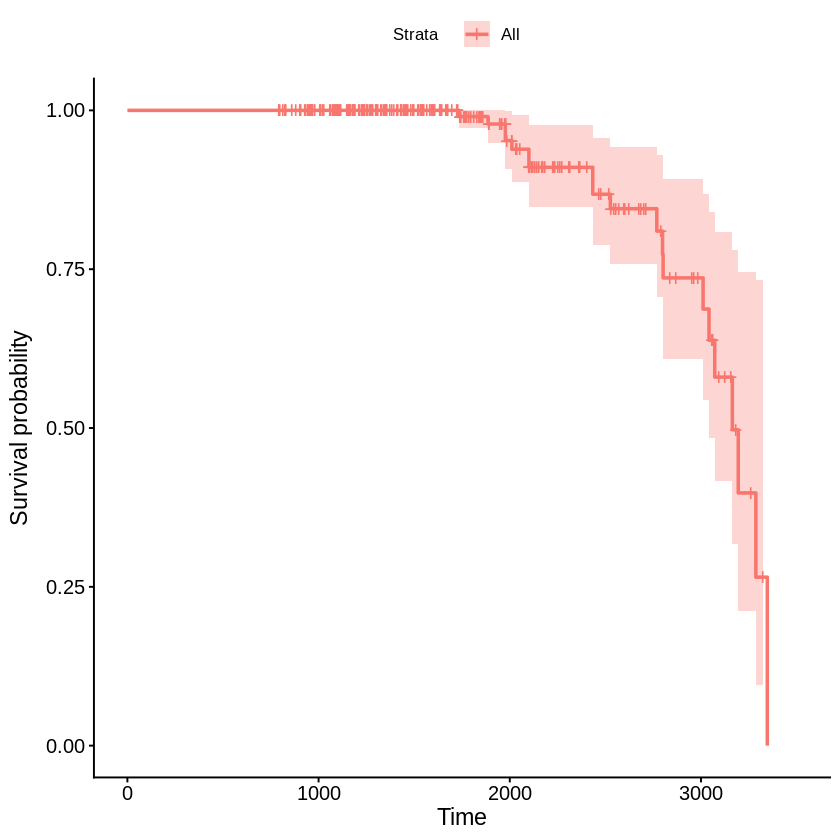

In [20]:
# Plot the event distribution of KM curve (0 points)
# Plot the Kaplan-Meier survival curve
ggsurvplot(km_basic, data = surv_cow)

# Part 3 (points: 10)
In this part you will have to fit non and semi-parametric survival models:
1. non-parametric survival analysis
2. Cox Proportional Hazards

## KM non-parametric analysis

In [ ]:
# Complete this code chunk (2 points)
surv_mod0 <- survfit(_________~ 1, data = surv_cow)
surv_mod1 <- survfit(_________~ daily_milk, data = surv_cow)
surv_mod2 <- survfit(_________~ scc + _______)
surv_mod3 <- survfit(_________~ scc + _______+ strata(lactation), data = surv_cow)

# Give all model summaries
summary()
___________
# Compare models; is it possible to use the following functions?
anova()
AIC()

In [ ]:
# Plotting (1 point; 2 bonus points)
ggsurvplot(surv_mod0, data = __________,risk.table = T, conf.int = T,_______)
# also display (i) median survival time and probability, (ii) cumulative events--
# --(iii) and censoring in this model

 For bonus points plot cumulative hazards with cumulative events using ggsurvplot and explain the relationship between median survival probability of cows in our dataset and baseline hazards of `surv_mod0` (2 sentences max; +2)

Answer the following questions for Part 3 (max points for questions = 2)
1. Which of the models is the best fit? Why? (1)
2. Is it better to fit lactation as a strata or as a variable? Why? (1) [Justify with code and output]

## Cox-Proportional Hazards model

In [ ]:
ph_mod0 <- coxph(surv_obj~1, data = surv_data)
ph_mod1 <- coxph(surv_obj ~ scc + daily_milk + strata(lactation), data = surv_data)
ph_mod2 <- coxph(surv_obj ~ scc + daily_milk, data = surv_data, weights = lactation)

Answer the following questions (max points for questions = 3)
1. Which of the cox models is the best fit? Justify with code and output (1)
2. What is the difference between `ph_mod1` and `ph_mod2`? (1.5)
3. What is the interpretation of the estimated `coef` and `exp(coef)` in the model summary? (1.5)

In [ ]:
# Plot the outcomes of the models using ggadjustedcurves() and ggforest()
ggadjustedcurves()
ggforest()

### Diagnostics (1 point)
Complete the following code chunk and answer the following:
1. For our best fitting model, does the assumptions of proportional hazard hold? If yes, why? if not, why not?
2. Plot the diagnostic test outcomes using either `plot(cox.zph())` or `ggcoxdiagnostics()`

In [ ]:
# code chunk for question 2

# Part 4 (points: 5)

Answer the following questions:
1. Based on all the previous analyses in this assignment, which variables explain the survival probabilities of the cows in the datasets? (1)
2. Which survival analysis technique will you choose for studying this type of data? Why? [Explain in 3-4 sentences] (2)
3. If we decide to use the model `ph_mod2`as our final model (might not be the best model), how can we determine the time for future events occuring? [code and output needed with 2-3 sentence explanation] (2)

# Part 5 (points: 5)
## Parametric Models (PH and AFT)

 - PH: Using Weibull and exponential distributions
 - AFT: Using Lognormal Distribution



In [ ]:
# use survreg function for fitting a weibull and exponential model with daily_milk as the independent variable
# 0.5 points
para_mod1 <- survreg(surv_obj ~ daily_milk, data = surv_cow, dist = "____", weights = lactation)
para_mod2 <- survreg(surv_obj ~ ___________, dist = "exponential",_______)

summary(_________)

In [ ]:
# Compare two models (0.5 point)
anova()
AIC()


Answer the following questions (2.5 points)
1. Which model is better fitted? Why? (1)
2. Interpret the `value` column in the summary. What does it mean? Explain the `value` of the `(Intercept)` and the `daily_milk`. How do the `value` differ from the `coef` of cox PH model in Part 3? (1.5)

In [ ]:
# use survreg to fit a lognormal model using the same formula as para_mod1 and 2
# 0.5 points
para_mod3 <- survreg(___________)
summary(_______)
# compare the model to para_mod1 and para_mod2

Answer the following question (1 point; Bonus 1 point):
1. What is the estimated time to next event for 1 unit increase of  `daily_milk`? Why? (1)
2. (Bonus) What does the `Scale` of the lognormal models signify in our data? (+1)